# Path1-Fine-grained specialty classification using GloVe Embeddings

This section implements the GloVe embedding branch of our clinical text mining 
pipeline, applied to Path 1 (fine-grained specialties, 9 classes with 100+ 
records each). The goal is to recover specialty structure from free-text 
clinical transcriptions, compare embedding-based classification performance, 
and surface where the model breaks down.

**Pipeline summary:**
1. Loaded and cleaned the dataset (dropped missing transcriptions, stripped 
   whitespace from specialty labels, removed the non-specialty "Consult - 
   History and Phy." category)
2. Tokenized transcription text using a custom clinical stopword list
3. Loaded pretrained GloVe embeddings (glove.6B.100d, Stanford NLP) and 
   built document vectors via mean-pooling, with OOV rate tracked (4.9%)
4. Tuned Linear SVC and Logistic Regression via Grid Search with 5-fold 
   cross-validation (searching C ∈ {0.01, 0.1, 1, 10, 100})
5. Evaluated the best model (Logistic Regression, C=1) on a held-out test set

**Key results:**
- Grid Search best CV macro-F1: Logistic Regression 0.505 (C=1) vs 
  Linear SVC 0.499 (C=0.1)
- Final held-out test macro-F1: 0.536
- Strongest classes: General Medicine, Obstetrics/Gynecology, Urology (recall 0.66–0.78)
- Weakest classes: Surgery (recall 0.29), Radiology (recall 0.35) — both 
  broad, cross-cutting specialties whose vocabulary overlaps with multiple 
  anatomical systems, causing systematic misclassification rather than 
  random error

**Note on preprocessing choices:** we initially tested lemmatization and 
stemming, but reverted to raw (cleaned, stopword-filtered) tokens after 
confirming stemming substantially increased the out-of-vocabulary rate 
(27% vs ~4-5%) by producing non-dictionary word fragments — a finding 
consistent with GloVe being trained on real, unstemmed English words.

In [ ]:
print(document_vector)
print(oov_rate)

<function document_vector at 0x000002476F405C70>
<function oov_rate at 0x000002476F405900>


In [1]:
#Loading the required libraries
import pandas as pd
import numpy as np
import re

In [2]:
#Load the data
mtsamples = pd.read_csv('../data/top_mtsamples.csv')

In [3]:
print(mtsamples.shape)
mtsamples.head()

(3104, 6)


,description,medical_specialty,sample_name,transcription,keywords,medical_specialty_clean
0,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple...",Cardiovascular / Pulmonary
1,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo...",Cardiovascular / Pulmonary
2,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 3,"2-D ECHOCARDIOGRAM,Multiple views of the heart...","cardiovascular / pulmonary, 2-d echocardiogram...",Cardiovascular / Pulmonary
3,Echocardiogram and Doppler,Cardiovascular / Pulmonary,2-D Echocardiogram - 4,"DESCRIPTION:,1. Normal cardiac chambers size....","cardiovascular / pulmonary, ejection fraction,...",Cardiovascular / Pulmonary
4,"Normal left ventricle, moderate biatrial enla...",Cardiovascular / Pulmonary,2-D Doppler,"2-D STUDY,1. Mild aortic stenosis, widely calc...","cardiovascular / pulmonary, 2-d study, doppler...",Cardiovascular / Pulmonary


In [4]:
mtsamples.columns

Index(['description', 'medical_specialty', 'sample_name', 'transcription',
       'keywords', 'medical_specialty_clean'],
      dtype='str')

In [5]:
#Droping rows with with no transcripts
mtsamples.dropna(subset=['transcription'], inplace=True)

In [6]:
mtsamples.shape

(3104, 6)

In [7]:
#Remove trailing whitespace from the medical specialty column
mtsamples['medical_specialty_clean'] = mtsamples['medical_specialty'].str.strip()

In [8]:
#medical specialty categories
mtsamples['medical_specialty_clean'].value_counts()

medical_specialty_clean
Surgery                       1088
Cardiovascular / Pulmonary     371
Orthopedic                     355
Radiology                      273
General Medicine               259
Gastroenterology               224
Neurology                      223
Urology                        156
Obstetrics / Gynecology        155
Name: count, dtype: int64

In [9]:
#Remove the note, report specialty, counsult-history and phy.
mtsamples = mtsamples[mtsamples['medical_specialty_clean'] != 'Consult - History and Phy.'].copy()
mtsamples['medical_specialty_clean'].value_counts()

medical_specialty_clean
Surgery                       1088
Cardiovascular / Pulmonary     371
Orthopedic                     355
Radiology                      273
General Medicine               259
Gastroenterology               224
Neurology                      223
Urology                        156
Obstetrics / Gynecology        155
Name: count, dtype: int64

In [10]:
#Filter to Path 1 — specialties with 100+ records
specialty_counts = mtsamples['medical_specialty_clean'].value_counts()
top_specialties = specialty_counts[specialty_counts >= 100].index

In [11]:
path1_df = mtsamples[mtsamples['medical_specialty_clean'].isin(top_specialties)].copy()
print(f"Number of classes: {path1_df['medical_specialty_clean'].nunique()}")
path1_df['medical_specialty_clean'].value_counts()

Number of classes: 9


medical_specialty_clean
Surgery                       1088
Cardiovascular / Pulmonary     371
Orthopedic                     355
Radiology                      273
General Medicine               259
Gastroenterology               224
Neurology                      223
Urology                        156
Obstetrics / Gynecology        155
Name: count, dtype: int64

In [12]:
#The stopswords 
with open('../data/clinical-stopwords.txt', 'r') as f:
    clinical_stopwords = set(line.strip().lower() for line in f if line.strip())

In [13]:
print(f"Loaded {len(clinical_stopwords)} clinical stopwords")
list(clinical_stopwords)[:10]

Loaded 808 clinical stopwords


['d',
 'particular',
 'shall',
 'appropriate',
 'samest',
 'donest',
 'appropriating',
 'with',
 'idemer',
 'unlike']

Tokenization

In [14]:
def tokenize_and_clean(text, stopword_set):
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = re.findall(r'\b[a-z]+\b', text)
    tokens = [t for t in tokens if t not in stopword_set and len(t) > 1]
    return tokens

In [15]:
#applying tokenization to our transcripts
path1_df['tokens'] = path1_df['transcription'].apply(lambda t: tokenize_and_clean(t, clinical_stopwords))

In [16]:
path1_df[['transcription', 'tokens']].head()

,transcription,tokens
0,"2-D M-MODE: , ,1. Left atrial enlargement wit...","[mode, left, atrial, enlargement, left, atrial..."
1,1. The left ventricular cavity size and wall ...,"[left, ventricular, cavity, size, wall, thickn..."
2,"2-D ECHOCARDIOGRAM,Multiple views of the heart...","[echocardiogram, multiple, views, heart, great..."
3,"DESCRIPTION:,1. Normal cardiac chambers size....","[description, normal, cardiac, chambers, size,..."
4,"2-D STUDY,1. Mild aortic stenosis, widely calc...","[study, mild, aortic, stenosis, widely, calcif..."


Vectorization (GloVe)

In [17]:
#Ceate a 'glove'sub-folder on the data folder 
import os
os.makedirs('../data/glove', exist_ok=True)

In [18]:
url = "https://nlp.stanford.edu/data/glove.6B.zip"
zip_path = "../data/glove.6B.zip"

In [22]:
import urllib.request

if not os.path.exists(zip_path):
    print("Downloading GloVe vectors...")
    urllib.request.urlretrieve(url, zip_path)
    print("Download complete.")
else:
    print("File already exists, skipping download.")

Download complete.


In [24]:
#Unzip the glove file 
import zipfile

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("../data/glove")

print("Extraction complete.")

Extraction complete.


In [25]:
import os
print(os.listdir('../data/glove'))

['glove.6B.50d.txt', 'glove.6B.200d.txt', 'glove.6B.100d.txt', 'glove.6B.300d.txt']


Loading the vectors into a dictionary

In [26]:
import numpy as np

embeddings_index = {}
with open('../data/glove/glove.6B.100d.txt', 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = vector

print(f"Loaded {len(embeddings_index)} real GloVe vectors.")

Loaded 400000 real GloVe vectors.


Define the function that averages word vectors for one document

In [27]:
def document_vector(tokens, embeddings, dim=100):
    valid_vectors = [embeddings[word] for word in tokens if word in embeddings]
    if not valid_vectors:
        return np.zeros(dim)
    return np.mean(valid_vectors, axis=0)

Define the function that checks the OOV rate for one document

In [28]:
def oov_rate(tokens, embeddings):
    if not tokens:
        return 0
    in_vocab = sum(1 for t in tokens if t in embeddings)
    return 1 - (in_vocab / len(tokens))

In [30]:
X = np.array([document_vector(tokens, embeddings_index) for tokens in path1_df['tokens']])

In [31]:
oov_rates = path1_df['tokens'].apply(lambda t: oov_rate(t, embeddings_index))

In [32]:
print(f"Vector matrix shape: {X.shape}")
print(f"Mean OOV rate: {oov_rates.mean():.3f}")

Vector matrix shape: (3104, 100)
Mean OOV rate: 0.049


Training , Hyperparameter tuning and Grid  search 

In [33]:
y = path1_df['medical_specialty_clean']

In [34]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

In [35]:
#Define the hyperparameter grid for Linear SVC
svc_param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

svc_grid = GridSearchCV(
    LinearSVC(class_weight='balanced', max_iter=5000, random_state=42),
    param_grid=svc_param_grid,
    scoring='f1_macro',
    cv=5
)
svc_grid.fit(X, y)

print("Best Linear SVC params:", svc_grid.best_params_)
print(f"Best Linear SVC macro-F1: {svc_grid.best_score_:.3f}")

Best Linear SVC params: {'C': 0.1}
Best Linear SVC macro-F1: 0.499


In [36]:
#Logistic regression Grid search
lr_param_grid = {'C': [0.01, 0.1, 1, 10, 100]}

lr_grid = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    param_grid=lr_param_grid,
    scoring='f1_macro',
    cv=5
)
lr_grid.fit(X, y)

print("Best Logistic Regression params:", lr_grid.best_params_)
print(f"Best Logistic Regression macro-F1: {lr_grid.best_score_:.3f}")

Best Logistic Regression params: {'C': 1}
Best Logistic Regression macro-F1: 0.505


Logistic Regression model

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

In [39]:
final_model = LogisticRegression(C=1, class_weight='balanced', max_iter=1000, random_state=42)
final_model.fit(X_train, y_train)
final_preds = final_model.predict(X_test)

In [40]:
from sklearn.metrics import classification_report, f1_score

print("Final test macro-F1:", f1_score(y_test, final_preds, average='macro'))
print(classification_report(y_test, final_preds))

Final test macro-F1: 0.5357362642121664
                            precision    recall  f1-score   support

Cardiovascular / Pulmonary       0.50      0.51      0.51       111
          Gastroenterology       0.47      0.66      0.55        67
          General Medicine       0.65      0.78      0.71        78
                 Neurology       0.49      0.72      0.58        67
   Obstetrics / Gynecology       0.49      0.76      0.60        46
                Orthopedic       0.44      0.69      0.53       107
                 Radiology       0.42      0.35      0.38        82
                   Surgery       0.68      0.29      0.41       327
                   Urology       0.44      0.74      0.55        47

                  accuracy                           0.51       932
                 macro avg       0.51      0.61      0.54       932
              weighted avg       0.55      0.51      0.50       932



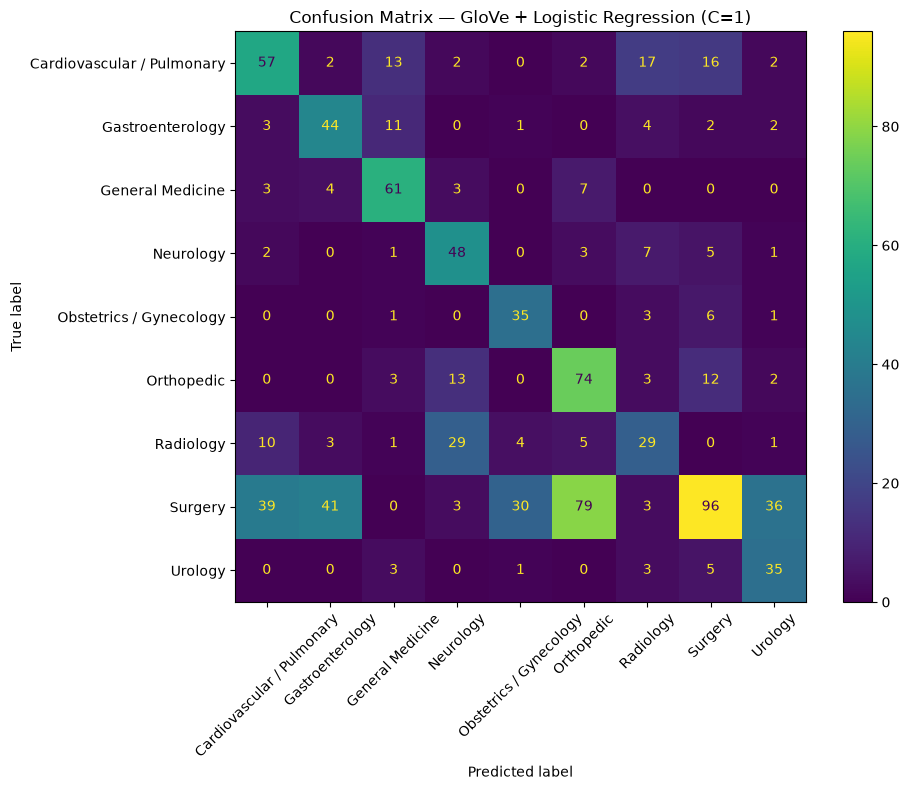

In [41]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(y_test, final_preds, xticks_rotation=45, ax=ax)
plt.title("Confusion Matrix — GloVe + Logistic Regression (C=1)")
plt.tight_layout()
plt.show()